Actividad práctica 4: Implementación de regresión lineal con TensorFlow

Objetivo: Aplicar un modelo de regresión para predecir resultados escolares.

Alcance: Introducción al aprendizaje supervisado.

Instrucciones:
Crear un dataset artificial: tareas entregadas vs. nota final.
Implementar regresión lineal con TensorFlow.
Visualizar la predicción y calcular el error.

Producto final: Notebook con modelo de regresión entrenado y validado.


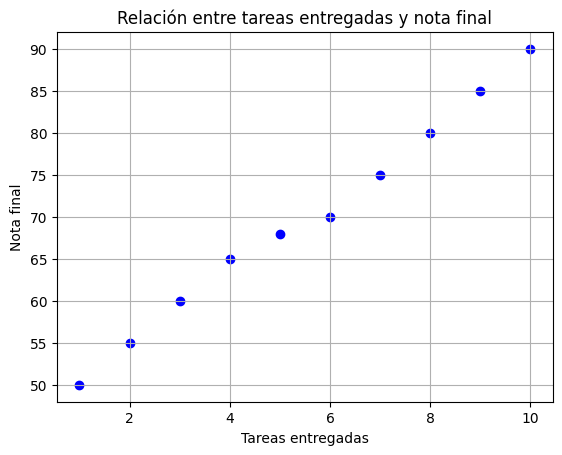

Epoch 0: pérdida = 5022.3999, W = 8.3800, b = 1.3960
Epoch 50: pérdida = 284.2001, W = 9.4540, b = 10.2025
Epoch 100: pérdida = 186.9286, W = 8.4674, b = 17.0711
Epoch 150: pérdida = 123.0703, W = 7.6680, b = 22.6364
Epoch 200: pérdida = 81.1475, W = 7.0202, b = 27.1457
Epoch 250: pérdida = 53.6252, W = 6.4954, b = 30.7993
Epoch 300: pérdida = 35.5570, W = 6.0702, b = 33.7596
Epoch 350: pérdida = 23.6953, W = 5.7257, b = 36.1582
Epoch 400: pérdida = 15.9081, W = 5.4465, b = 38.1016
Epoch 450: pérdida = 10.7959, W = 5.2203, b = 39.6763


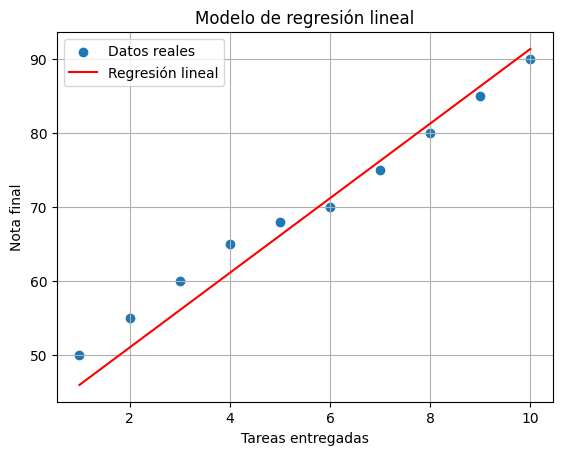

Predicción de nota para 7.0 tareas entregadas: 76.21
Error cuadrático medio final: 7.44


In [1]:
# Paso 1: Importar librerías necesarias
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Paso 2: Crear un dataset artificial (tareas entregadas vs nota final)
# Supongamos 10 estudiantes
tareas_entregadas = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
nota_final = np.array([50, 55, 60, 65, 68, 70, 75, 80, 85, 90], dtype=float)

# Paso 3: Visualizar los datos
plt.scatter(tareas_entregadas, nota_final, color='blue')
plt.xlabel('Tareas entregadas')
plt.ylabel('Nota final')
plt.title('Relación entre tareas entregadas y nota final')
plt.grid(True)
plt.show()

# Paso 4: Normalizar los datos (opcional pero recomendable)
x = tareas_entregadas
y = nota_final

# Paso 5: Definir variables y modelo de regresión lineal
W = tf.Variable(0.0)
b = tf.Variable(0.0)

# Paso 6: Definir la función de predicción
def modelo_lineal(x):
    return W * x + b

# Paso 7: Definir la función de pérdida (MSE)
def loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

# Paso 8: Optimizador
optimizador = tf.optimizers.SGD(learning_rate=0.01)

# Paso 9: Entrenamiento del modelo
for epoch in range(500):
    with tf.GradientTape() as tape:
        pred = modelo_lineal(x)
        current_loss = loss(y, pred)
    grad = tape.gradient(current_loss, [W, b])
    optimizador.apply_gradients(zip(grad, [W, b]))

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: pérdida = {current_loss.numpy():.4f}, W = {W.numpy():.4f}, b = {b.numpy():.4f}")

# Paso 10: Visualizar la línea de regresión
plt.scatter(x, y, label='Datos reales')
plt.plot(x, modelo_lineal(x), color='red', label='Regresión lineal')
plt.xlabel('Tareas entregadas')
plt.ylabel('Nota final')
plt.title('Modelo de regresión lineal')
plt.legend()
plt.grid(True)
plt.show()

# Paso 11: Predicción de una nueva nota con 7 tareas entregadas
nueva_tarea = 7.0
prediccion = modelo_lineal(nueva_tarea)
print(f"Predicción de nota para {nueva_tarea} tareas entregadas: {prediccion.numpy():.2f}")

# Paso 12: Calcular error cuadrático medio final
error_final = loss(y, modelo_lineal(x))
print(f"Error cuadrático medio final: {error_final.numpy():.2f}")
